In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import celltypist 

print("Scanpy:", sc.__version__)
print("AnnData:", ad.__version__)

Scanpy: 1.10.3
AnnData: 0.10.9


In [2]:
import warnings   ## Import the warnings module to manage and silence non-critical system alerts

# Suppress PerformanceWarnings from pandas, which often occur when highly 
# fragmented DataFrames are created during large-scale single-cell data processing
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)  

In [3]:
 # Import the os module to interact with the operating system, 
# allowing for file path management and directory navigation
import os

In [4]:
##ad is reserved for AnnData (the library that handles the data structure Scanpy uses).
import anndata as ad ## Import anndata using the 'ad' alias 

In [5]:
# Set the current working directory to the specified folder for saving plots
os.chdir("D:/Bidya Work/single/GSE245601_Breast_Cancer/Phase1")
os.getcwd()                                   

'D:\\Bidya Work\\single\\GSE245601_Breast_Cancer\\Phase1'

In [6]:
# Load the Phase 1 AnnData object
# This object contains the processed Seurat data, including PCA/UMAP and Harmony-corrected information from the R workflow.
GSE245601_phase1 = ad.read_h5ad("D:/Bidya Work/single/GSE245601_Breast_Cancer/Phase1/GSE245601_harmony_phase1_corrected.h5ad")

GSE245601_phase1

AnnData object with n_obs × n_vars = 57420 × 17430
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'GSM', 'Title', 'percent.mt', 'percent.rb', 'Condition', 'pca_clusters', 'seurat_clusters', 'harmony_nn_res.0.8', 'ident'
    uns: 'X_name'
    obsm: 'HARMONY', 'PCA', 'UMAP'
    layers: 'logcounts'

In [7]:
# Check the available embeddings

print("Embeddings:", list(GSE245601_phase1.obsm.keys()))

Embeddings: ['HARMONY', 'PCA', 'UMAP']


In [8]:
# Check Normal vs Tumor cell counts

print("Condition:")
print(GSE245601_phase1.obs["Condition"].value_counts())

print("\nSeurat clusters:")
print(GSE245601_phase1.obs["seurat_clusters"].value_counts().sort_index())

print("\nGSM samples:")
print(GSE245601_phase1.obs["GSM"].value_counts().sort_index())

Condition:
Condition
Tumor     43653
Normal    13767
Name: count, dtype: int64

Seurat clusters:
seurat_clusters
0     7266
1     5474
2     5418
3     4696
4     4536
5     4558
6     4201
7     4087
8     3891
9     3589
10    1737
11    1721
12    1687
13    1417
14    1343
15     953
16     549
17     151
18     132
19       4
20       2
21       2
22       2
23       2
24       2
Name: count, dtype: int64

GSM samples:
GSM
GSM7845546     3320
GSM7845548    10447
GSM7845552     6186
GSM7845554     4543
GSM7845556     3910
GSM7845558     1855
GSM7845560     4092
GSM7845562     6082
GSM7845564     5913
GSM7845566     2653
GSM7845568     4644
GSM7845570     3775
Name: count, dtype: int64


UMAP dimensions: (57420, 2)
AnnData cells: 57420
All AnnData cells found in UMAP CSV: True
Stored UMAP shape: (57420, 2)


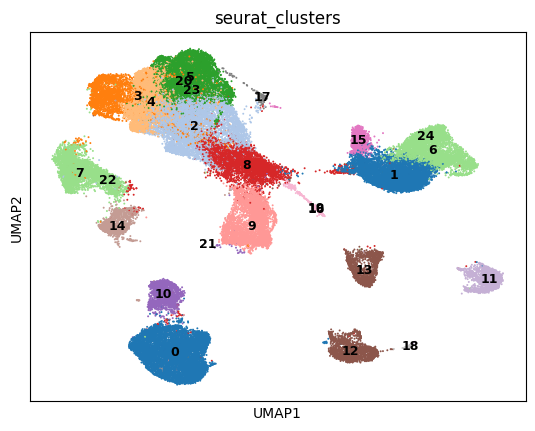

In [9]:
# Load and align UMAP coordinates exported from Seurat

umap_df = pd.read_csv("D:/Bidya Work/single/GSE245601_Breast_Cancer/Phase1/GSE245601_harmony_phase1_umap_coordinates.csv",  index_col=0)

# Verify dimensions and cell matching
print("UMAP dimensions:", umap_df.shape)
print("AnnData cells:", GSE245601_phase1.n_obs)
print(  "All AnnData cells found in UMAP CSV:",  GSE245601_phase1.obs_names.isin(umap_df.index).all())

# Align UMAP coordinates to the exact cell order in AnnData
GSE245601_phase1.obsm["X_umap"] = umap_df.loc[ GSE245601_phase1.obs_names].values

print("Stored UMAP shape:", GSE245601_phase1.obsm["X_umap"].shape)

# Visualize Seurat clusters with axes

sc.pl.umap(
    GSE245601_phase1,
    color="seurat_clusters",
    palette="tab20",
    legend_loc="on data",
    legend_fontsize=9,
    frameon=True,
    size=8)

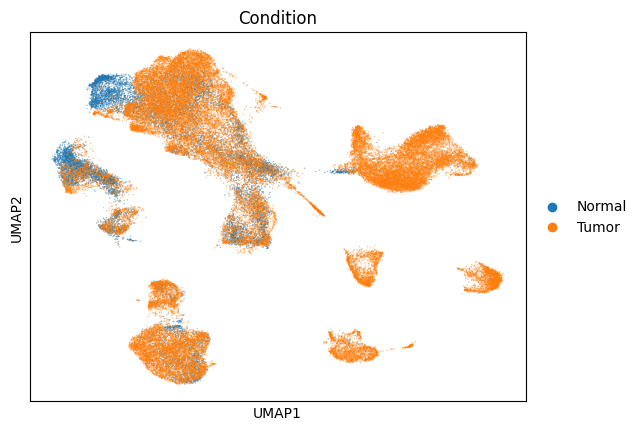

In [10]:
# Visualize Normal vs Tumor distribution

sc.pl.umap(
    GSE245601_phase1,
    color="Condition",
    frameon=True,
    size=4,
    alpha=0.5
)

In [11]:
# Calculate Normal vs Tumor composition within each Seurat cluster

cluster_condition = pd.crosstab(
    GSE245601_phase1.obs["seurat_clusters"],
    GSE245601_phase1.obs["Condition"]
)

cluster_condition_pct = (
    cluster_condition
    .div(cluster_condition.sum(axis=1), axis=0)
    * 100
)

print("Cell counts:")
display(cluster_condition)

print("\nPercentage of cells within each cluster:")
display(cluster_condition_pct.round(2))

Cell counts:


Condition,Normal,Tumor
seurat_clusters,,
0,1421,5845
1,38,5436
2,845,4573
3,4056,640
4,309,4227
5,77,4481
6,57,4144
7,2852,1235
8,1653,2238



Percentage of cells within each cluster:


Condition,Normal,Tumor
seurat_clusters,,
0,19.56,80.44
1,0.69,99.31
2,15.60,84.40
3,86.37,13.63
4,6.81,93.19
5,1.69,98.31
6,1.36,98.64
7,69.78,30.22
8,42.48,57.52


In [12]:
import celltypist

print("CellTypist version:", celltypist.__version__)

print("\nAvailable local models:")
print(celltypist.models.models_path)

CellTypist version: 1.7.1

Available local models:
C:\Users\HP\.celltypist\data\models


In [13]:
import os

model_dir = r"C:\Users\HP\.celltypist\data\models"

models = [
    f for f in os.listdir(model_dir)
    if f.endswith(".pkl")
]

for model in sorted(models):
    print(model)

Cells_Adult_Breast.pkl


In [14]:
import celltypist

# Show the models available for download
models = celltypist.models.models_description()
print(models)

👉 Detailed model information can be found at `https://www.celltypist.org/models`


                                      model  \
0                        Immune_All_Low.pkl   
1                       Immune_All_High.pkl   
2                    Adult_COVID19_PBMC.pkl   
3   Adult_CynomolgusMacaque_Hippocampus.pkl   
4                       Adult_Human_MTG.pkl   
..                                      ...   
56                   Nuclei_Lung_Airway.pkl   
57       PaediatricAdult_COVID19_Airway.pkl   
58         PaediatricAdult_COVID19_PBMC.pkl   
59                      Pan_Fetal_Human.pkl   
60                Thymus_Allograft_PBMC.pkl   

                                          description  
0   immune sub-populations combined from 20 tissue...  
1   immune populations combined from 20 tissues of...  
2   peripheral blood mononuclear cell types from C...  
3   cell types from the hippocampus of adult cynom...  
4   cell types and subtypes (10x-based) from the a...  
..                                                ...  
56  cell populations from snRNA-seq of five

In [15]:
# Filter CellTypist's model list for models potentially relevant
# to breast cancer / solid-tissue annotation.

keywords = ["breast", "cancer", "tumor", "mammary", "epithelial", "tissue"]

relevant_models = models[
    models["description"].str.contains(
        "|".join(keywords),
        case=False,
        na=False
    )
]

print(relevant_models.to_string(index=False))

                       model                                                                                                           description
          Immune_All_Low.pkl                                                         immune sub-populations combined from 20 tissues of 18 studies
         Immune_All_High.pkl                                                             immune populations combined from 20 tissues of 18 studies
      Cells_Adult_Breast.pkl                                                                                cell types from the adult human breast
 Developing_Human_Gonads.pkl        cell types of human gonadal and adjacent extragonadal tissue from the first and second trimesters of gestation
 Human_Colorectal_Cancer.pkl                                                      cell types of colon tissues from patients with colorectal cancer
Mouse_Dendritic_Subtypes.pkl          dendritic cell subtypes integrated from 9 datasets across murine spleen, bone ma

In [16]:
import celltypist

# Download the adult human breast CellTypist model
celltypist.models.download_models(
    force_update=False,
    model="Cells_Adult_Breast.pkl"
)

print("Adult breast model downloaded.")

📂 Storing models in C:\Users\HP\.celltypist\data\models
💾 Total models to download: 1
⏩ Skipping [1/1]: Cells_Adult_Breast.pkl (file exists)


Adult breast model downloaded.


In [17]:
import os
import shutil

source = r"C:\Users\HP\.celltypist\data\models\Cells_Adult_Breast.pkl"
destination = r"D:/Bidya Work/single/GSE245601_Breast_Cancer/Phase1/Cells_Adult_Breast.pkl"

shutil.copy2(source, destination)

print("Copied to:")
print(destination)
print("File exists:", os.path.exists(destination))

Copied to:
D:/Bidya Work/single/GSE245601_Breast_Cancer/Phase1/Cells_Adult_Breast.pkl
File exists: True


In [18]:
GSE245601_phase1.X = GSE245601_phase1.layers["logcounts"].copy()
sc.pp.neighbors( GSE245601_phase1,  use_rep="HARMONY") # 1. Build the neighbor graph using Harmony-corrected embeddings
sc.tl.leiden( GSE245601_phase1,  resolution=10, key_added="celltypist_clusters") # 2. Generate high-resolution clusters for CellTypist over-clustering
print(GSE245601_phase1)
print(GSE245601_phase1.obsm["HARMONY"].shape)
print(GSE245601_phase1.obs["celltypist_clusters"].nunique())

# 3. Predict cell types using the adult human breast model
ct_pred = celltypist.annotate(
    GSE245601_phase1,
    model=r"D:/Bidya Work/single/GSE245601_Breast_Cancer/Phase1/Cells_Adult_Breast.pkl",
    majority_voting=True,
    over_clustering="celltypist_clusters")

# 4. View predicted cell types
print(ct_pred.predicted_labels.head())

🔬 Input data has 57420 cells and 17430 genes
🔗 Matching reference genes in the model


AnnData object with n_obs × n_vars = 57420 × 17430
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'GSM', 'Title', 'percent.mt', 'percent.rb', 'Condition', 'pca_clusters', 'seurat_clusters', 'harmony_nn_res.0.8', 'ident', 'celltypist_clusters'
    uns: 'X_name', 'seurat_clusters_colors', 'Condition_colors', 'neighbors', 'celltypist_clusters'
    obsm: 'HARMONY', 'PCA', 'UMAP', 'X_umap'
    layers: 'logcounts'
    obsp: 'distances', 'connectivities'
(57420, 100)
141


🧬 3787 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
🗳️ Majority voting the predictions
✅ Majority voting done!


                                                   predicted_labels  \
GSM7845546_Normal_01_Control.h5_AAACCCAAGTCAGGGT-1      Fibro-major   
GSM7845546_Normal_01_Control.h5_AAACCCACATCACAGT-1      Fibro-major   
GSM7845546_Normal_01_Control.h5_AAACCCATCTCAATCT-1       Vas-venous   
GSM7845546_Normal_01_Control.h5_AAACGAACAAGTTCGT-1            basal   
GSM7845546_Normal_01_Control.h5_AAACGAACACAACGAG-1      Fibro-major   

                                                   over_clustering  \
GSM7845546_Normal_01_Control.h5_AAACCCAAGTCAGGGT-1              23   
GSM7845546_Normal_01_Control.h5_AAACCCACATCACAGT-1             100   
GSM7845546_Normal_01_Control.h5_AAACCCATCTCAATCT-1              33   
GSM7845546_Normal_01_Control.h5_AAACGAACAAGTTCGT-1              10   
GSM7845546_Normal_01_Control.h5_AAACGAACACAACGAG-1               5   

                                                   majority_voting  
GSM7845546_Normal_01_Control.h5_AAACCCAAGTCAGGGT-1     Fibro-major  
GSM7845546_Nor

In [19]:
# Count the total number of high-resolution Leiden clusters
# generated for CellTypist over-clustering.
print( f"Number of clusters created: " f"{GSE245601_phase1.obs['celltypist_clusters'].nunique()}")

Number of clusters created: 141


In [20]:
# Transfer CellTypist majority-voting predictions to the AnnData object.
# Convert labels to strings for compatibility with Scanpy plotting functions.
GSE245601_phase1.obs["majority_voting"] = ( ct_pred.predicted_labels["majority_voting"] .astype(str))

# Display the 5 most frequent cell types.
print( GSE245601_phase1.obs["majority_voting"]
    .value_counts()
    .head())

majority_voting
LummHR-major    15892
Lumsec-basal     7792
Fibro-major      6796
CD4-naive        3774
LummHR-SCGB      2700
Name: count, dtype: int64


... storing 'majority_voting' as categorical


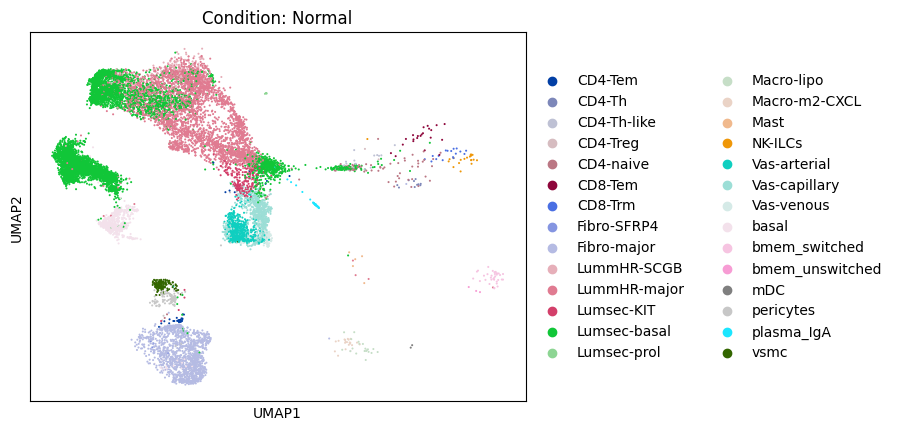

... storing 'majority_voting' as categorical


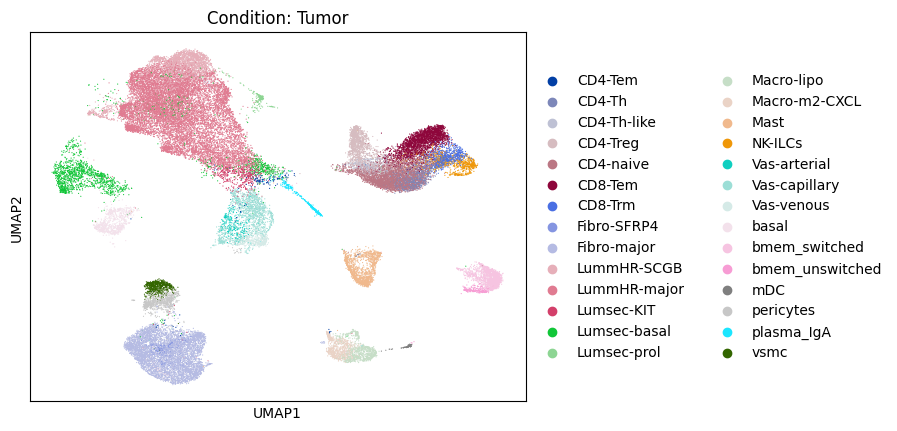

In [21]:
import os
import matplotlib.pyplot as plt
import scanpy as sc

# Create output directory if it doesn't exist
out_dir = "D:/Bidya Work/single/GSE245601_Breast_Cancer/Phase1/"
os.makedirs(out_dir, exist_ok=True)

# Generate a UMAP for each condition
for cond in GSE245601_phase1.obs["Condition"].unique():

    adata_subset = GSE245601_phase1[
        GSE245601_phase1.obs["Condition"] == cond]

    fig = sc.pl.umap(
        adata_subset,
        color="majority_voting",
        title=f"Condition: {cond}",
        legend_loc="right margin",
        show=False,
        return_fig=True)

    fig.savefig(
        os.path.join(
            out_dir,
            f"umap_celltypes_celltypist_{cond}.png"),
        dpi=300,
        bbox_inches="tight")

    plt.show()
    plt.close(fig)

In [22]:
pd.crosstab(
    GSE245601_phase1.obs["majority_voting"],
    GSE245601_phase1.obs["Condition"]
)

Condition,Normal,Tumor
majority_voting,,
CD4-Tem,41,148
CD4-Th,10,1039
CD4-Th-like,21,405
CD4-Treg,2,1453
CD4-naive,78,3696
CD8-Tem,22,2472
CD8-Trm,17,761
Fibro-SFRP4,7,330
Fibro-major,1358,5438


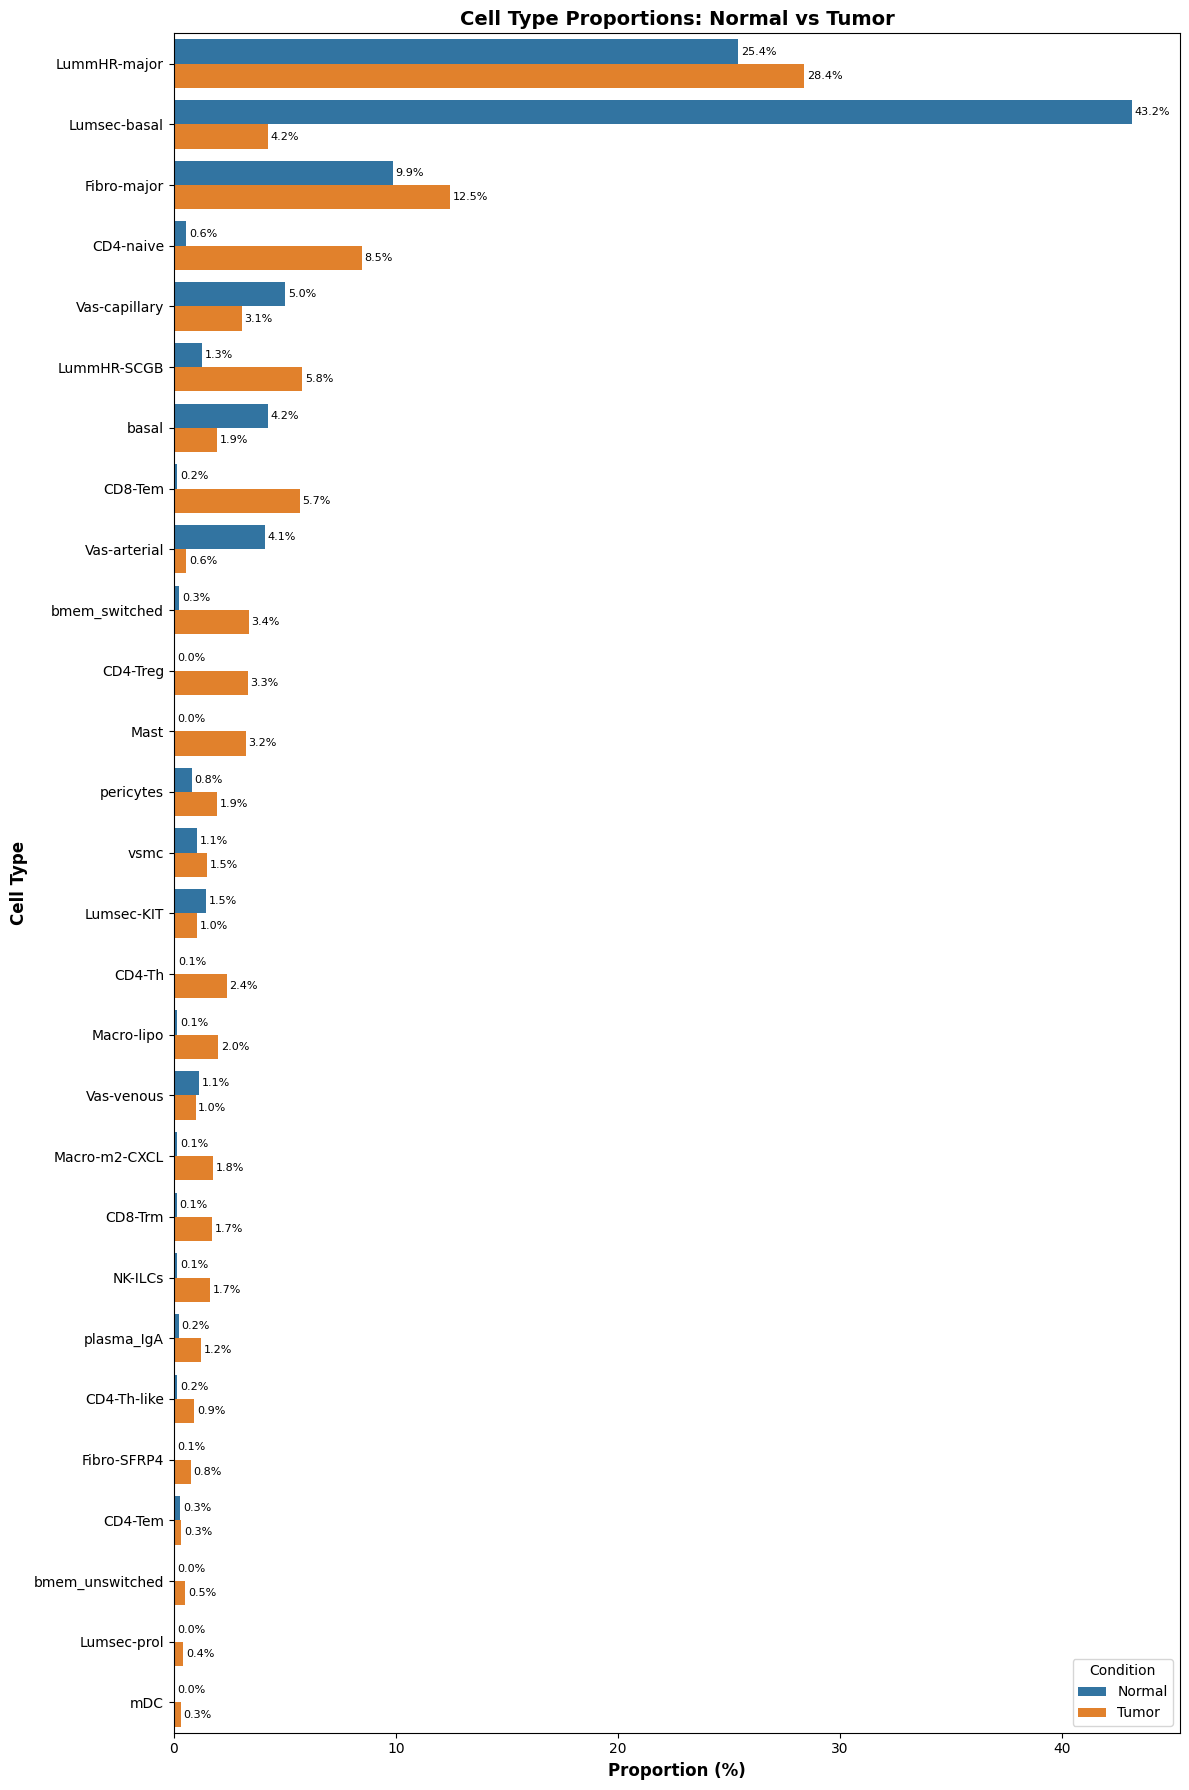

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Count cells for each CellTypist cell type within each condition
n_cells_condition = (
    GSE245601_phase1.obs
    .groupby(["Condition", "majority_voting"])
    .size()
    .reset_index(name="count")
)

# Step 2: Calculate cell-type proportions within each condition
n_cells_condition["total"] = (
    n_cells_condition
    .groupby("Condition")["count"]
    .transform("sum")
)

n_cells_condition["proportion"] = (
    n_cells_condition["count"] /
    n_cells_condition["total"]
) * 100

# Step 3: Order cell types by their average proportion
avg_proportions = (
    n_cells_condition
    .groupby("majority_voting")["proportion"]
    .mean()
    .sort_values(ascending=False)
)

ordered_celltypes = avg_proportions.index.tolist()

# Step 4: Generate horizontal bar plot
plt.figure(figsize=(12, 18))

ax = sns.barplot(
    data=n_cells_condition,
    y="majority_voting",
    x="proportion",
    hue="Condition",
    order=ordered_celltypes,
    dodge=True
)

# Step 5: Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="edge",
        padding=2,
        fontsize=8
    )

plt.xlabel("Proportion (%)", fontsize=12, fontweight="bold")
plt.ylabel("Cell Type", fontsize=12, fontweight="bold")
plt.title(
    "Cell Type Proportions: Normal vs Tumor",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "D:/Bidya Work/single/GSE245601_Breast_Cancer/Phase1/Cellproportions_barplot.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# Save the table
n_cells_condition.to_csv(
    "D:/Bidya Work/single/GSE245601_Breast_Cancer/Phase1/Cellproportions.csv",
    index=False
)

In [24]:
# Create a combined cell-type + condition label
# Format: "CellType_Condition" (e.g., "Lumsec-basal_Normal")

GSE245601_phase1.obs["celltype_condition"] = (
    GSE245601_phase1.obs["majority_voting"].astype(str)
    + "_"
    + GSE245601_phase1.obs["Condition"].astype(str))
GSE245601_phase1.obs["celltype_condition"].value_counts()

celltype_condition
LummHR-major_Tumor        12394
Lumsec-basal_Normal        5942
Fibro-major_Tumor          5438
CD4-naive_Tumor            3696
LummHR-major_Normal        3498
LummHR-SCGB_Tumor          2522
CD8-Tem_Tumor              2472
Lumsec-basal_Tumor         1850
bmem_switched_Tumor        1472
CD4-Treg_Tumor             1453
Mast_Tumor                 1414
Fibro-major_Normal         1358
Vas-capillary_Tumor        1336
CD4-Th_Tumor               1039
Macro-lipo_Tumor            869
basal_Tumor                 844
pericytes_Tumor             841
Macro-m2-CXCL_Tumor         778
CD8-Trm_Tumor               761
NK-ILCs_Tumor               721
Vas-capillary_Normal        692
vsmc_Tumor                  662
basal_Normal                584
Vas-arterial_Normal         564
plasma_IgA_Tumor            536
Lumsec-KIT_Tumor            450
Vas-venous_Tumor            428
CD4-Th-like_Tumor           405
Fibro-SFRP4_Tumor           330
Vas-arterial_Tumor          248
bmem_unswitched_Tumor

In [25]:
def find_unique_markers(
    adata, 
    groupby="celltype_condition", 
    method="wilcoxon", 
    pval_threshold=0.05, 
    logfc_threshold=0.25,
    top_n=3,
    min_cells_per_group=2
):
    """
    Identify significant and unique DEGs for each cell-type/condition group.
    """

    # 1. Remove groups with too few cells
    group_counts = adata.obs[groupby].value_counts()
    valid_groups = group_counts[
        group_counts >= min_cells_per_group
    ].index.tolist()

    # 2. Subset to valid groups
    adata_filtered = adata[
        adata.obs[groupby].isin(valid_groups)
    ].copy()

    # 3. Differential expression analysis
    sc.tl.rank_genes_groups(
        adata_filtered,
        groupby=groupby,
        method=method )

    # 4. Extract DE results
    all_degs = sc.get.rank_genes_groups_df(
        adata_filtered,
        group=None )

    # 5. Filter by adjusted p-value and logFC
    filtered_degs = all_degs[
        (all_degs["pvals_adj"] < pval_threshold) &
        (abs(all_degs["logfoldchanges"]) > logfc_threshold)]

    # 6. Keep genes significant in only one group
    unique_genes = (
        filtered_degs
        .groupby("names")["group"]
        .nunique()
        .reset_index()
        .query("group == 1")["names"]
        .tolist() )

    # 7. Keep only unique DEGs
    unique_degs_df = filtered_degs[
        filtered_degs["names"].isin(unique_genes)
    ].copy()

    # 8. Select top N DEGs per group
    top_unique_degs_df = (
        unique_degs_df
        .sort_values(
            ["group", "logfoldchanges"],
            ascending=[True, False] )
        .groupby("group")
        .head(top_n)
        .reset_index(drop=True) )

    return top_unique_degs_df


# Run on GSE245601 Phase 1
top_markers = find_unique_markers(
    GSE245601_phase1,
    groupby="celltype_condition",
    method="wilcoxon",
    pval_threshold=0.05,
    logfc_threshold=0.25,
    top_n=3,
    min_cells_per_group=2)

print(top_markers)

... storing 'majority_voting' as categorical
... storing 'celltype_condition' as categorical


               group    names     scores  logfoldchanges          pvals  \
0       CD4-Th_Tumor  B3GALT2   3.812304        4.656080   1.376777e-04   
1     CD4-Treg_Tumor    FOXP3  17.772234        9.019729   1.159777e-70   
2     CD4-Treg_Tumor    LAIR2   4.180727        7.009485   2.905790e-05   
3     CD4-Treg_Tumor     GNG8   4.684713        6.735691   2.803522e-06   
4    CD4-naive_Tumor   CD40LG   3.639995        3.973404   2.726435e-04   
..               ...      ...        ...             ...            ...   
75  plasma_IgA_Tumor   DUSP26   6.021977        9.293736   1.722987e-09   
76  plasma_IgA_Tumor    DERL3  27.351984        8.928080  1.022776e-164   
77        vsmc_Tumor      SRL  12.050127        7.057829   1.936513e-33   
78        vsmc_Tumor     FHL5   4.959976        6.538548   7.050199e-07   
79        vsmc_Tumor    RERGL   7.928202        6.478850   2.223416e-15   

        pvals_adj  
0    4.839125e-04  
1    5.028584e-69  
2    9.279575e-05  
3    9.887777e-06  

In [26]:
# 1. Identify the top 3 highly specific markers for each cell type/condition group
# Uses the Wilcoxon rank-sum test to identify significant genes
# that are exclusive to only one group.

unique_markers = find_unique_markers(
    GSE245601_phase1,
    groupby="celltype_condition",
    method="wilcoxon",
    pval_threshold=0.05,
    logfc_threshold=0.25,
    top_n=3,
    min_cells_per_group=2
)

# 2. Validation and Export
print(unique_markers.head())

print(
    unique_markers["group"].drop_duplicates()
)

unique_markers.to_csv(
    "D:/Bidya Work/single/GSE245601_Breast_Cancer/Phase1/Unique_cluster_markers.csv",
    index=False
)

... storing 'majority_voting' as categorical
... storing 'celltype_condition' as categorical


             group    names     scores  logfoldchanges         pvals  \
0     CD4-Th_Tumor  B3GALT2   3.812304        4.656080  1.376777e-04   
1   CD4-Treg_Tumor    FOXP3  17.772234        9.019729  1.159777e-70   
2   CD4-Treg_Tumor    LAIR2   4.180727        7.009485  2.905790e-05   
3   CD4-Treg_Tumor     GNG8   4.684713        6.735691  2.803522e-06   
4  CD4-naive_Tumor   CD40LG   3.639995        3.973404  2.726435e-04   

      pvals_adj  
0  4.839125e-04  
1  5.028584e-69  
2  9.279575e-05  
3  9.887777e-06  
4  5.869059e-04  
0              CD4-Th_Tumor
1            CD4-Treg_Tumor
4           CD4-naive_Tumor
7             CD8-Tem_Tumor
10        Fibro-SFRP4_Tumor
13       Fibro-major_Normal
16        Fibro-major_Tumor
19        LummHR-SCGB_Tumor
22      LummHR-major_Normal
25       LummHR-major_Tumor
28         Lumsec-KIT_Tumor
29      Lumsec-basal_Normal
32       Lumsec-basal_Tumor
35        Lumsec-prol_Tumor
38         Macro-lipo_Tumor
41      Macro-m2-CXCL_Tumor
44         

... storing 'majority_voting' as categorical
... storing 'celltype_condition' as categorical


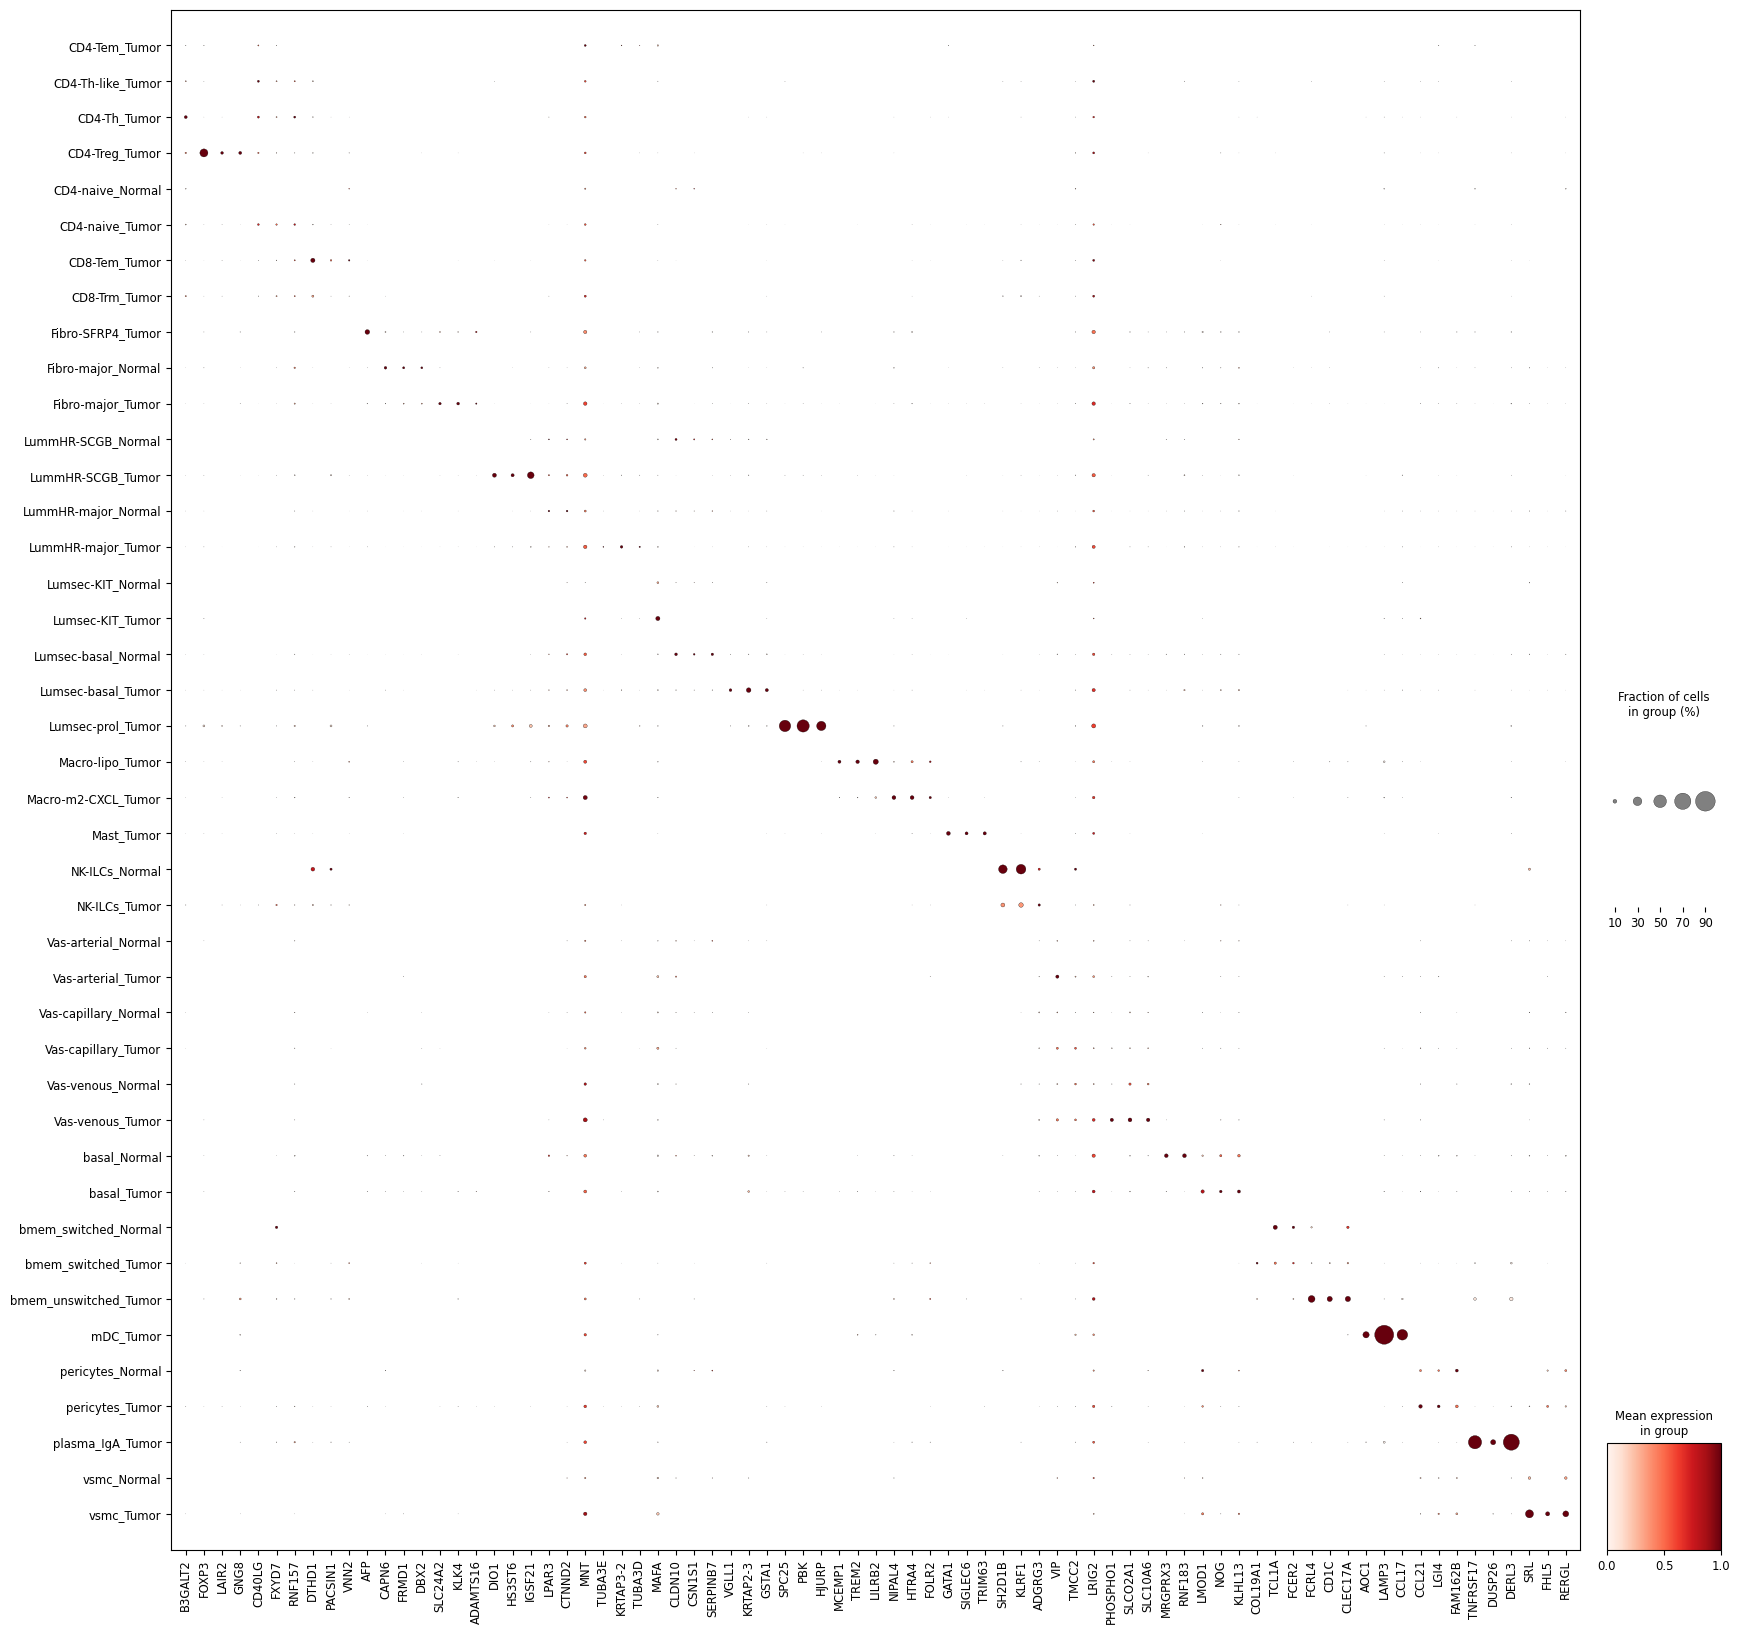

In [36]:
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

# 1. Subset Data
# Remove any populations you do not want to include in the visualization.
excluded_prefixes = []
mask = ~GSE245601_phase1.obs["celltype_condition"].str.startswith(
    tuple(excluded_prefixes)
) if excluded_prefixes else np.ones(
    GSE245601_phase1.n_obs, dtype=bool
)

adata_to_plot = GSE245601_phase1[mask].copy()


# 2. Filter Gene List
# Keep only marker genes that are present in the expression matrix.
genes_to_plot = unique_markers["names"].tolist()
genes_to_plot = [
    g for g in genes_to_plot
    if g in adata_to_plot.var_names
]


# 3. Data Transformation
X = adata_to_plot[:, genes_to_plot].X

if hasattr(X, "toarray"):
    X = X.toarray()


# 4. Aggregation
# Calculate total expression for each gene within each
# cell-type/condition group.
expr_df = pd.DataFrame(
    X,
    index=adata_to_plot.obs["celltype_condition"],
    columns=genes_to_plot
)

expr_per_group = expr_df.groupby(expr_df.index).sum()


# 5. Filter Weak Markers
# Keep genes with substantial expression in at least one group.
genes_filtered = expr_per_group.columns[
    expr_per_group.max(axis=0) >= 30
].tolist()

expr_per_group = expr_per_group[genes_filtered]


# 6. Filter Groups
# Keep groups with sufficient total expression signal.
valid_groups = expr_per_group.index[
    expr_per_group.sum(axis=1) > 20
].tolist()

adata_to_plot = adata_to_plot[
    adata_to_plot.obs["celltype_condition"].isin(valid_groups)
].copy()


# 7. Dot Plot
# Color is scaled independently for each gene (0–1),
# making group-specific expression patterns easier to visualize.
sc.pl.dotplot(
    adata_to_plot,
    var_names=genes_filtered,
    groupby="celltype_condition",
    standard_scale="var",
    show=False,
    figsize=(20, 20),
    dendrogram=False
)

plt.savefig(
    "D:/Bidya Work/single/GSE245601_Breast_Cancer/Phase1/"
    "Celltype_condition_Markergenes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
GSE245601_phase1


AnnData object with n_obs × n_vars = 57420 × 17430
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'GSM', 'Title', 'percent.mt', 'percent.rb', 'Condition', 'pca_clusters', 'seurat_clusters', 'harmony_nn_res.0.8', 'ident', 'celltypist_clusters', 'majority_voting', 'celltype_condition'
    uns: 'X_name', 'seurat_clusters_colors', 'Condition_colors', 'neighbors', 'celltypist_clusters'
    obsm: 'HARMONY', 'PCA', 'UMAP', 'X_umap'
    layers: 'logcounts'
    obsp: 'distances', 'connectivities'

In [ ]:
GSE245601_phase1.write(
    "D:/Bidya Work/single/GSE245601_Breast_Cancer/Phase1/GSE245601_phase1_celltypist.h5ad"
)

In [30]:
unique_markers[
    unique_markers["group"] == "CD4-Th_Tumor"
]


,group,names,scores,logfoldchanges,pvals,pvals_adj
0,CD4-Th_Tumor,B3GALT2,3.812304,4.65608,0.000138,0.000484
